In [6]:
import pynapple as nap
import numpy as np
import pandas as pd
import rsatoolbox
from monkeypaw.io import nap_load_data,get_spike_count,get_behav,get_info
from monkeypaw.proc import compute_perievent, get_index_from_info


# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-5-Animals-3&4\sub-Dataset-5-Animals-3&4.nwb"
# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-3-Animals-1-to-4\sub-Dataset-3-Animals-1-to-4.nwb"
nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-4-Animal-3-sess-1-to-6\sub-Dataset-4-Animal-3-sess-1-to-6.nwb"
# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-5-Animals-2-ses-20-to-39\sub-Dataset-5-Animals-2-ses-20-to-39.nwb"
data = nap_load_data(nwb_path)

# actually load in data
spike_count = get_spike_count(data)
behav = get_behav(data)
info = get_info(data)

# get perievent
all_peth = compute_perievent(spike_count, behav, info, win = (-1,2))

Original keys: ['spikes_counts', 'trial_id', 'session', 'datasetID', 'animal', 'result', 'EventTarget_Onset', 'EventGo_cue', 'target_dir', 'target_ID', 'force_y', 'force_x', 'cursor_vel_y', 'cursor_vel_x', 'cursor_pos_y', 'cursor_pos_x', 'cursor_acc_y', 'cursor_acc_x']


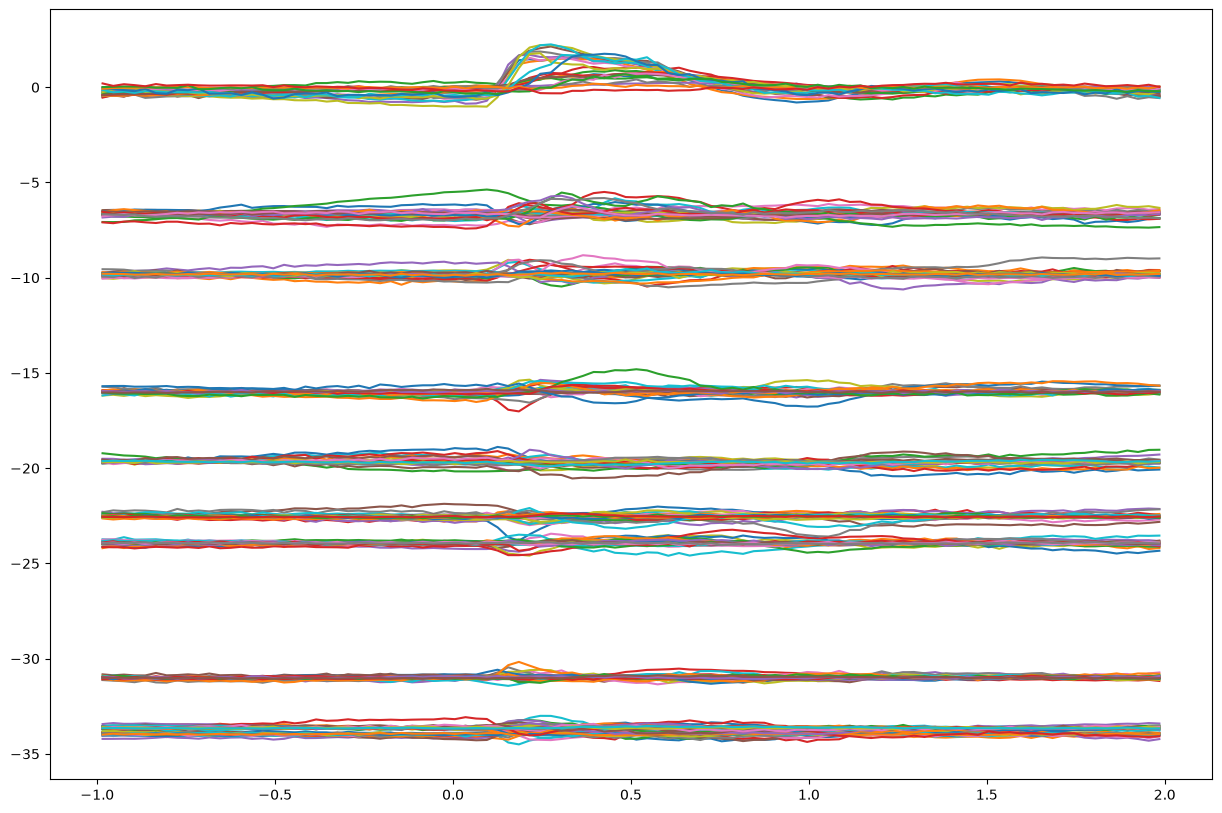

In [ ]:
from monkeypaw.proc import get_top_n_PC

# get one session
as_idx = get_index_from_info(all_peth['info_go'],["animal","session"], out_pos=True)

# loop through session 
peth_go = all_peth['peth_go']
d = np.zeros((peth_go.shape[0],peth_go.shape[1],10))
t = peth_go.times()
for k,idx in as_idx.items():
    d[:,idx,:] = get_top_n_PC(peth_go[:,idx,:], npc=10)
pcpeth_go = nap.TsdTensor(t=t,d=d,time_units='s')

import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,1,figsize=(15,10))
offsets = np.max(pcpeth_go, axis=(0,1))*.9
# take averate of pc by session
avg_pcpeth_go = np.zeros((pcpeth_go.shape[0],len(as_idx),pcpeth_go.shape[2]))
for i,(k, idx) in enumerate(as_idx.items()):
    avg_pcpeth_go[:,i,:] = np.mean(pcpeth_go[:,idx,:], axis=1)

    
for i in range(pcpeth_go.shape[2]):
    ax.plot(pcpeth_go.times(),avg_pcpeth_go[:,:,i]-offsets[i]*i, label=f'PC {i+1}')

In [ ]:
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA

def get_top_n_PC(peth, npc=10):
    """
    Fit PCA to one session's PETH data.

    Parameters
    ----------
    peth
        nap.TsdTensor with shape: (n_time, n_event, n_cell)

    npc
        Number of desired principal components.

    Returns
    -------
    pc_scores : np.ndarray
        PCA scores with shape:
        (n_time, n_event, npc)

    pca : sklearn.decomposition.PCA
        Fitted PCA model.
    """
    nt, nev, ncell = peth.shape

    if npc > ncell:
        raise ValueError(f"npc={npc} is too large. Maximum allowed is " f"{ncell}.")

    # Convert from time × event × cell
    # to observation × cell
    peth_dat = np.asarray(peth.data()).reshape(-1, ncell)

    # Replace nonfinite values
    peth_dat = np.nan_to_num(
        peth_dat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    pca = PCA(n_components=npc)

    pc_scores = pca.fit_transform(peth_dat)
    pc_scores = pc_scores.reshape(nt, nev, npc)

    return pc_scores, pca

def align_session_pcs(session_pc_scores, reference_index=0):
    """
    Align separately fitted session PCA spaces using orthogonal Procrustes.

    Parameters
    ----------
    session_pc_scores : list of np.ndarray
        Each array has shape:
        (n_time, n_event, n_pc)

    reference_index : int
        Session used as the reference coordinate system.

    Returns
    -------
    aligned_scores : list of np.ndarray
        Aligned event-level scores.

    aligned_means : np.ndarray
        Shape:
        (n_time, n_session, n_pc)

    rotations : list of np.ndarray
        Procrustes rotation for each session.
    """
    templates = [
        scores.mean(axis=1)
        for scores in session_pc_scores
    ]

    reference = templates[reference_index]

    # Center the template across time before fitting rotation
    reference_centered = (
        reference - reference.mean(axis=0, keepdims=True)
    )

    aligned_scores = []
    rotations = []

    for scores, template in zip(
        session_pc_scores,
        templates,
    ):
        template_centered = (
            template
            - template.mean(axis=0, keepdims=True)
        )

        R, _ = orthogonal_procrustes(
            template_centered,
            reference_centered,
        )

        # R operates on the final PC dimension
        scores_aligned = scores @ R

        aligned_scores.append(scores_aligned)
        rotations.append(R)

    return aligned_scores, rotations

In [23]:
def convert_peth_to_pcpeth(ev_peth, ev_info, npc=10):
    # Placeholder for the actual implementation
    sess_idx = get_index_from_info(ev_info, ["session"], out_pos=True)
    sess_pcscores = []
    sess_infos = []
    for sess, indices in sess_idx.items():
        sess_peth = ev_peth[:, indices, :]
        sess_ev_info = ev_info.iloc[indices]
        pc_scores, pca = get_top_n_PC(sess_peth, npc=npc)
        sess_pcscores.append(pc_scores)
        sess_infos.append(sess_ev_info)
    # Align the session PCA spaces
    aligned_sess_pc, rotations = align_session_pcs(sess_pcscores, reference_index=0)
    # combine the aligned session PCA scores into a single tensor
    pc_d = np.concatenate(aligned_sess_pc, axis=1)
    pc_t = ev_peth.times()
    ev_pcpeth = nap.TsdTensor(t=pc_t, d=pc_d, time_units='s')
    return ev_pcpeth

# example single animal data
peth = all_peth['peth_go']
ev_info = all_peth['info_go']
animal_idx = get_index_from_info(ev_info, ["animal"], out_pos=True)
idx = animal_idx[list(animal_idx.keys())[0]]

pc_peth = convert_peth_to_pcpeth(peth[:,idx,:], ev_info.iloc[idx], npc=10)

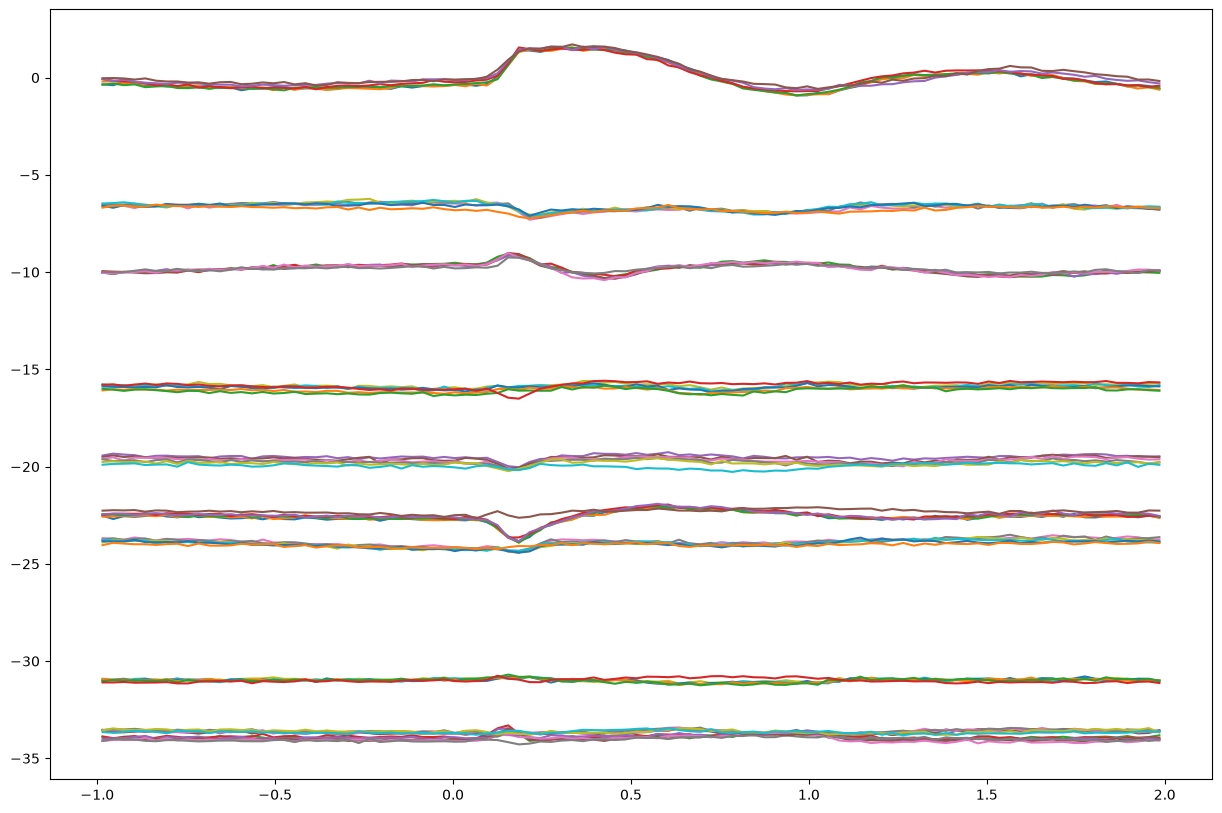

In [25]:
as_idx = get_index_from_info(ev_info,["session"], out_pos=True)

import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,1,figsize=(15,10))
offsets = np.max(pcpeth_go, axis=(0,1))*.9
# take averate of pc by session
avg_pcpeth_go = np.zeros((pcpeth_go.shape[0],len(as_idx),pcpeth_go.shape[2]))
for i,(k, idx) in enumerate(as_idx.items()):
    avg_pcpeth_go[:,i,:] = np.mean(pcpeth_go[:,idx,:], axis=1)

    
for i in range(pcpeth_go.shape[2]):
    ax.plot(pcpeth_go.times(),avg_pcpeth_go[:,:,i]-offsets[i]*i, label=f'PC {i+1}')

In [12]:
filtered_info = all_peth['info_go']
peth = all_peth['peth_go']
obs_descrip = {'target_dir': filtered_info["target_dir"].values,
                'target_ID': filtered_info["target_ID"].values,
                'result': filtered_info["result"].values}
rep_bin = peth.restrict(nap.IntervalSet(start=0, end=0.5)).mean(axis=0)
print(peth.shape, rep_bin.shape,obs_descrip['result'].shape)
dataset = rsatoolbox.data.Dataset(rep_bin, obs_descriptors=obs_descrip)

(100, 1173, 96) (1173, 96) (1173,)


In [ ]:
def make_rdm_datasets(peth:nap.TsdTensor, ev_info:pd.DataFrame, **kwargs):
    """
    Make RDM datasets from perievent data and event info.
    
    Parameters
    ----------
    peth : nap.TsdTensor
        Perievent time series data.
    ev_info : pd.DataFrame
        Event information corresponding to the perievent data.
    **kwargs : dict
        Additional keyword arguments for filtering or processing the data.
    
    Returns
    -------
    rdm_datasets : dict
        A dictionary containing RDM datasets for different conditions or groups.
    """

    # Break down the peth and ev_info into segment defined by animal
    animal_idx = get_index_from_info(ev_info, 'animal')

        
    # Example implementation (to be customized based on specific requirements)
    rdm_datasets = {k: None for k in animal_idx.keys()}

    # loop through animal and make each animal a dataset
    for animal, indices in animal_idx.items():
        animal_peth = peth[:,indices,:]
        animal_ev_info = ev_info.iloc[indices]

        # Check what brain region we are at, if more than 1 in 1 animal, we drop the animal
        # We also drop Area2
        brain_regions = np.unique(animal_ev_info["brain_region"])
        if len(brain_regions) > 1 or "Area2" in brain_regions:
            print(f"Animal {animal} has multiple brain regions or contains Area2. Skipping this animal.")
            continue
        elif "PMd" in brain_regions:
            npc = 15
        elif "M1" in brain_regions:
            npc = 10
        else:
            print(f"Animal {animal} has an unrecognized brain region: {brain_regions}. Skipping this animal.")
            continue

        # TODO: session level processsing (get PCA, and rebase to common base within animal)
        # Placeholder for actual session-level processing logic
        pcpeth = convert_peth_to_pcpeth(animal_peth, animal_ev_info, npc=10)

        # TODO: Filter events based on specific criteria (if needed)
        filtered_info = animal_ev_info  # Placeholder for actual filtering logic
        filtered_peth = pcpeth  # Placeholder for actual filtering logic

        # TODO: split data by reach direaction

        # TODO: take average of a smaller window of time around the event

        # TODO: take average by target direction
        rep_bin = animal_peth
        obs_descrip = {'target_dir': filtered_info["target_dir"].values,
                       'target_ID': filtered_info["target_ID"].values,
                       'result': filtered_info["result"].values}
        ch_descrip = {'animal': filtered_info['animal'].values,
                    'session': filtered_info['session'].values,
                    'brain_region': filtered_info['brain_region'].values}

        rdm_dataset = rsatoolbox.data.Dataset(rep_bin, 
                                              obs_descriptors=obs_descrip,
                                              channel_descriptors=ch_descrip)
            
        rdm_datasets[animal] = rdm_dataset
    # clear out empty datasets
    rdm_datasets = {k: v for k, v in rdm_datasets.items() if v is not None}
    return rdm_datasets
